In [1]:
import numpy as np
from scipy.optimize import bisect
from InfAdjFPFiniteDiffApp import InfAdjFPFiniteDiff_ScipySp
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigs

In [2]:
dim = 2
mpl = 1.221e19
Pi = 100**0.5
M = 1e16 / mpl
phic = np.sqrt(2) * M
# phic = (3 * beta)**(-0.5)
# M = phic / 2**0.5
Lambda = (1e-15)**0.25
nWaterfall = 1
psic = (nWaterfall * Lambda**4 * Pi / 48 / 2**0.5 / np.pi**1.5)**0.5
beta = 10

def infPotFunc(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * ((1 - (psi / M)**2)**2 + 2 * (phi * psi / phic / M)**2 + beta * (phi - phic)**3))
    
def infPotDerivFunc_phi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (4 * phi * (psi / phic / M)**2 + 3 * beta * (phi - phic)**2))
    
def infPotDerivFunc_psi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (-4 * psi / M**2 * (1 - (psi / M)**2) + 4 * psi * (phi / phic / M)**2))

def infPotDeriv2Func_phi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (4 * (psi / phic / M)**2 + 6 * beta * (phi - phic)))

def infPotDeriv2Func_psi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (-4 / M**2 + 12 * (psi / M / M)**2 + 4 * (phi / phic / M)**2))

def infPotDeriv2Func_phipsi(Phi):
    phi = Phi[0]
    psi = Phi[1]
    return float(Lambda**4 * (8 * phi * psi / (phic * M)**2))

def eta_psi(Phi):
    return infPotDeriv2Func_psi(Phi) / infPotFunc(Phi)

def etaCl_phi(Phi):
    v = infPotFunc(Phi) / 24 / np.pi**2
    vDer = infPotDerivFunc_phi(Phi) / 24 / np.pi**2
    vDer2 = infPotDeriv2Func_phi(Phi) / 24 / np.pi**2
    return abs(2 * v - vDer2 * v**2 / vDer**2)

def etaCl_psi(Phi):
    v = infPotFunc(Phi) / 24 / np.pi**2
    vDer = infPotDerivFunc_psi(Phi) / 24 / np.pi**2
    vDer2 = infPotDeriv2Func_psi(Phi) / 24 / np.pi**2
    return abs(2 * v - vDer2 * v**2 / vDer**2)


infPotentialDerivFuncs = [infPotDerivFunc_phi, infPotDerivFunc_psi]
infPotentialDeriv2Funcs = [[infPotDeriv2Func_phi, infPotDeriv2Func_phipsi], [infPotDeriv2Func_phipsi, infPotDeriv2Func_psi]]

nGrid = 1000

In [3]:
deltaPhiWell = 2 * (2 / 3 * Lambda**4 / beta) ** (1 / 3)
phiLargeEtaMax = bisect(lambda phi: etaCl_phi([phi, 0]) - 0.1, phic + 0.01 * deltaPhiWell, phic + 10 * deltaPhiWell)
phiLargeEtaMax = 2 * phiLargeEtaMax - phic 
phiLargeEtaMin = phic - (phiLargeEtaMax - phic)

# 以下は1912.05399に準拠。下限はad hoc
phimax = phic + beta**(-1/3)
phimin = phic - beta**(-1/3)

In [4]:
psiLargeEtaMax = bisect(lambda psi: etaCl_psi([phiLargeEtaMax, psi]) - 0.1, 0.0001 * psic, 1000 * psic)
psiLargeEtaMin = -psiLargeEtaMax 

psimax = bisect(lambda psi: eta_psi([phic, psi]) - 1, 0, M)
psimin = -psimax

In [5]:
customGrid_phi = np.concatenate([phic - np.exp(np.linspace(np.log(phic - phimin), np.log(phic - phiLargeEtaMin), nGrid // 4, endpoint=False)),
                                 np.linspace(phiLargeEtaMin, phiLargeEtaMax, nGrid // 2),
                                 phic + np.exp(np.linspace(np.log(phiLargeEtaMax - phic), np.log(phimax - phic), nGrid // 4 + 1)[1:])])
customGrid_psi = np.concatenate([-np.exp(np.linspace(np.log(psimax), np.log(psiLargeEtaMax), nGrid // 4 + 1))[:-1],
                                 np.linspace(psiLargeEtaMin, psiLargeEtaMax, nGrid // 2),
                                 np.exp(np.linspace(np.log(psiLargeEtaMax), np.log(psimax), nGrid // 4 + 1))[1:]])

In [6]:
phic

0.0011582420658256308

In [7]:
customGrid_phi

array([-4.63000641e-01, -4.41229736e-01, -4.20479973e-01, -4.00703457e-01,
       -3.81854539e-01, -3.63889710e-01, -3.46767503e-01, -3.30448397e-01,
       -3.14894721e-01, -3.00070575e-01, -2.85941741e-01, -2.72475605e-01,
       -2.59641085e-01, -2.47408555e-01, -2.35749779e-01, -2.24637847e-01,
       -2.14047109e-01, -2.03953119e-01, -1.94332577e-01, -1.85163277e-01,
       -1.76424053e-01, -1.68094735e-01, -1.60156094e-01, -1.52589808e-01,
       -1.45378410e-01, -1.38505256e-01, -1.31954480e-01, -1.25710962e-01,
       -1.19760290e-01, -1.14088728e-01, -1.08683185e-01, -1.03531183e-01,
       -9.86208310e-02, -9.39407940e-02, -8.94802695e-02, -8.52289613e-02,
       -8.11770565e-02, -7.73152022e-02, -7.36344843e-02, -7.01264068e-02,
       -6.67828721e-02, -6.35961625e-02, -6.05589224e-02, -5.76641409e-02,
       -5.49051363e-02, -5.22755399e-02, -4.97692822e-02, -4.73805779e-02,
       -4.51039134e-02, -4.29340336e-02, -4.08659298e-02, -3.88948283e-02,
       -3.70161794e-02, -

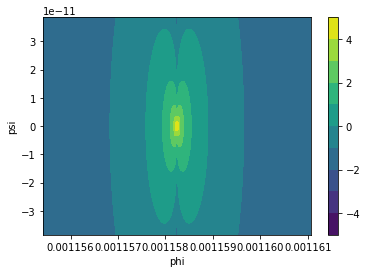

In [8]:
etaCls = np.zeros((nGrid, nGrid))
for i in range(nGrid):
    for j in range(nGrid):
        etaCls[i,j] = etaCl_phi([customGrid_phi[i], customGrid_psi[j]])

fig, ax1 = plt.subplots(1)
cntr1 = ax1.contourf(customGrid_phi, customGrid_psi, np.log10(etaCls.T), levels=np.linspace(-5, 5, 11))
fig.colorbar(cntr1, ax=ax1)
ax1.set_xlabel("phi")
ax1.set_ylabel("psi")
ax1.set_xlim([phiLargeEtaMin, phiLargeEtaMax])
ax1.set_ylim([psiLargeEtaMin, psiLargeEtaMax])
plt.show()

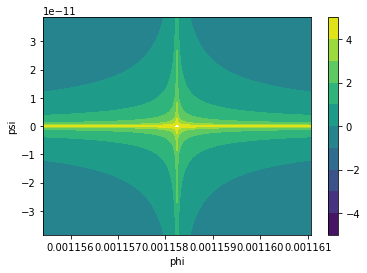

In [9]:
etaCls = np.zeros((nGrid, nGrid))
for i in range(nGrid):
    for j in range(nGrid):
        etaCls[i,j] = etaCl_psi([customGrid_phi[i], customGrid_psi[j]])

fig, ax1 = plt.subplots(1)
cntr1 = ax1.contourf(customGrid_phi, customGrid_psi, np.log10(etaCls.T), levels=np.linspace(-5, 5, 11))
fig.colorbar(cntr1, ax=ax1)
ax1.set_xlabel("phi")
ax1.set_ylabel("psi")
ax1.set_xlim([phiLargeEtaMin, phiLargeEtaMax])
ax1.set_ylim([psiLargeEtaMin, psiLargeEtaMax])
plt.show()

In [10]:
fpFinDiff_NeuDir = InfAdjFPFiniteDiff_ScipySp(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    [nGrid, nGrid],
    [phimax, psimax],
    [phimin, -psimax],
    ["Neumann0OriFunc", "Dirichlet"],
    ["Dirichlet", "Dirichlet"],
    customGrid=[customGrid_phi, customGrid_psi],
    set0OutOfInfRegion=False
)

# # ポテンシャルが一定以下ならインフレーション領域外として、当該点に対応する行列の要素を0とする
# customGrid_phi_woEnd = customGrid_phi[1:-1]
# customGrid_psi_woEnd = customGrid_psi[1:-1]
# vTh = (1 - 4.746948205088901201275e-16) * Lambda**4
# maskMat = np.full((len(customGrid_phi_woEnd), len(customGrid_psi_woEnd)), False)
# for i1 in range(len(customGrid_phi_woEnd)):
#     for i2 in range(len(customGrid_psi_woEnd)):
#         if infPotFunc([customGrid_phi_woEnd[i1], customGrid_phi_woEnd[i2]]) < vTh:
#             maskMat[i1, i2] = True
#             fpFinDiff_NeuNeu[i1, i2] = 0

eigVals_NeuDir, eigVecs_NeuDir = eigs(fpFinDiff_NeuDir, 10, sigma=0, which='LM')
eigVecsSort_NeuDir = eigVecs_NeuDir.T[np.argsort(np.abs(eigVals_NeuDir))]
eigValsSort_NeuDir = eigVals_NeuDir[np.argsort(np.abs(eigVals_NeuDir))]

In [11]:
np.set_printoptions(formatter={'float': '{:.15e}'.format})
print(fpFinDiff_NeuDir)
np.set_printoptions()

  (0, 0)	4.66064884515484e+29
  (0, 1)	-0.015175393010677064
  (0, 998)	-1.9385080804263777e-15
  (1, 0)	-0.01624803146709825
  (1, 1)	4.441992806034628e+29
  (1, 2)	-0.01670244924242577
  (1, 999)	-1.929847992994959e-15
  (2, 1)	-0.017281636681963804
  (2, 2)	4.2285021534123204e+29
  (2, 3)	-0.01777189657536644
  (2, 1000)	-1.9217586573291636e-15
  (3, 2)	-0.01838816902282732
  (3, 3)	4.02069145386421e+29
  (3, 4)	-0.018916799913439357
  (3, 1001)	-1.9142024574602652e-15
  (4, 3)	-0.019572773941385346
  (4, 4)	3.818981023560688e+29
  (4, 5)	-0.020142483136124125
  (4, 1002)	-1.9071442565377657e-15
  (5, 4)	-0.020840959932204847
  (5, 5)	3.623704110925324e+29
  (5, 6)	-0.021454645754935373
  (5, 1003)	-1.9005512334406108e-15
  (6, 5)	-0.022198624147603232
  (6, 6)	3.4351142807924966e+29
  :	:
  (995997, 995997)	1.5958859907366374e+26
  (995997, 995998)	-0.28798522434509344
  (995998, 995000)	-3.507667573942485e-14
  (995998, 995997)	-0.27833350976603943
  (995998, 995998)	1.70652599154

In [12]:
fpFinDiff_DirDir = InfAdjFPFiniteDiff_ScipySp(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    [nGrid, nGrid],
    [phimax, psimax],
    [phimin, -psimax],
    ["Dirichlet", "Dirichlet"],
    ["Dirichlet", "Dirichlet"],
    customGrid=[customGrid_phi, customGrid_psi],
    set0OutOfInfRegion=False
)

# for i1 in range(len(customGrid_phi_woEnd)):
#     for i2 in range(len(customGrid_psi_woEnd)):
#         if maskMat[i1, i2]: fpFinDiff_DirDir[i1, i2] = 0

eigVals_DirDir, eigVecs_DirDir = eigs(fpFinDiff_DirDir, 10, sigma=0, which='LM')
eigVecsSort_DirDir = eigVecs_DirDir.T[np.argsort(np.abs(eigVals_DirDir))]
eigValsSort_DirDir = eigVals_DirDir[np.argsort(np.abs(eigVals_DirDir))]

In [13]:
np.set_printoptions(formatter={'float': '{:.15e}'.format})
print(fpFinDiff_DirDir)
np.set_printoptions()

  (0, 0)	4.66064884515484e+29
  (0, 1)	-0.015175393010677064
  (0, 998)	-1.9385080804263777e-15
  (1, 0)	-0.01624803146709825
  (1, 1)	4.441992806034628e+29
  (1, 2)	-0.01670244924242577
  (1, 999)	-1.929847992994959e-15
  (2, 1)	-0.017281636681963804
  (2, 2)	4.2285021534123204e+29
  (2, 3)	-0.01777189657536644
  (2, 1000)	-1.9217586573291636e-15
  (3, 2)	-0.01838816902282732
  (3, 3)	4.02069145386421e+29
  (3, 4)	-0.018916799913439357
  (3, 1001)	-1.9142024574602652e-15
  (4, 3)	-0.019572773941385346
  (4, 4)	3.818981023560688e+29
  (4, 5)	-0.020142483136124125
  (4, 1002)	-1.9071442565377657e-15
  (5, 4)	-0.020840959932204847
  (5, 5)	3.623704110925324e+29
  (5, 6)	-0.021454645754935373
  (5, 1003)	-1.9005512334406108e-15
  (6, 5)	-0.022198624147603232
  (6, 6)	3.4351142807924966e+29
  :	:
  (995997, 995997)	1.5958859907366374e+26
  (995997, 995998)	-0.28798522434509344
  (995998, 995000)	-1.681148301274773e-14
  (995998, 995997)	-0.27833350976603943
  (995998, 995998)	1.70652599154

c:\Users\koich\anaconda3\lib\site-packages\numpy\core\_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


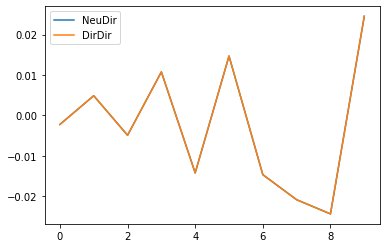

In [14]:
ax = plt.gca()
plt.plot(eigValsSort_NeuDir, label = "NeuDir")
plt.plot(eigValsSort_DirDir, label = "DirDir")
plt.legend()
plt.show()

In [15]:
np.set_printoptions(formatter={'float': '{:.30e}'.format})
print(eigValsSort_NeuDir[0:10])
print(eigValsSort_DirDir[0:10])
np.set_printoptions()

[-0.00226423+0.j  0.0048562 +0.j -0.00494187+0.j  0.01075412+0.j
 -0.01426327+0.j  0.0146856 +0.j -0.01470249+0.j -0.02090552+0.j
 -0.02441942+0.j  0.02454036+0.j]
[-0.00226423+0.j  0.0048562 +0.j -0.00494187+0.j  0.01075412+0.j
 -0.01426327+0.j  0.0146856 +0.j -0.01470249+0.j -0.02090552+0.j
 -0.02441942+0.j  0.02454036+0.j]


c:\Users\koich\anaconda3\lib\site-packages\matplotlib\contour.py:1454: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmax = float(z.max())
c:\Users\koich\anaconda3\lib\site-packages\matplotlib\contour.py:1455: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmin = float(z.min())
c:\Users\koich\anaconda3\lib\site-packages\numpy\ma\core.py:2825: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,


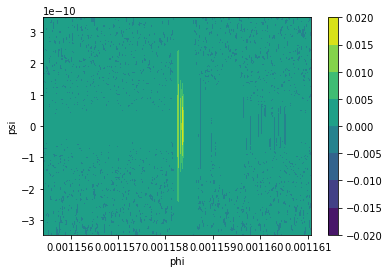

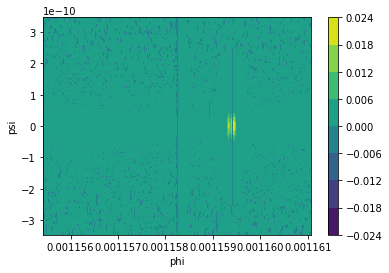

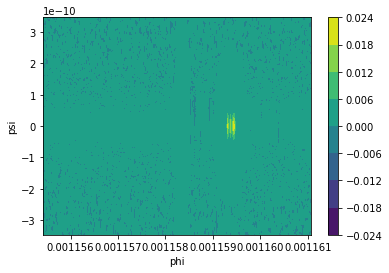

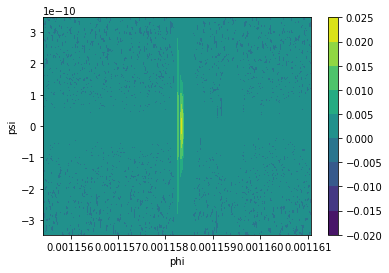

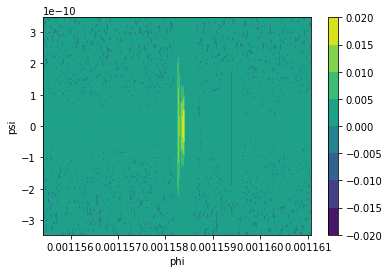

In [16]:
# 固有関数のプロット
customGrid_phi_woEnd = customGrid_phi[1:-1]
customGrid_psi_woEnd = customGrid_psi[1:-1]

for iEig in range(5):   
    fig, ax1 = plt.subplots(1)
    cntr1 = ax1.contourf(customGrid_phi_woEnd, customGrid_psi_woEnd, np.reshape(eigVecsSort_NeuDir[iEig], (nGrid-2, nGrid-2)).T)
    fig.colorbar(cntr1, ax=ax1)
    ax1.set_xlabel("phi")
    ax1.set_ylabel("psi")
    ax1.set_xlim([phiLargeEtaMin, phiLargeEtaMax])
    ax1.set_ylim([5 * psiLargeEtaMin - 4 * psiLargeEtaMax, 5 * psiLargeEtaMax - 4 * psiLargeEtaMin])
    plt.show()

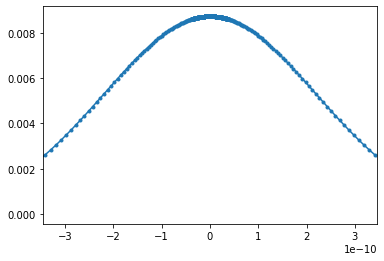

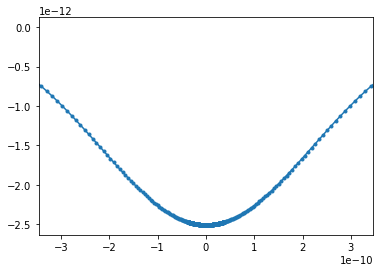

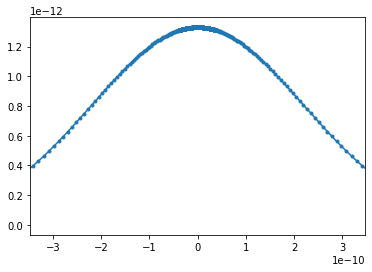

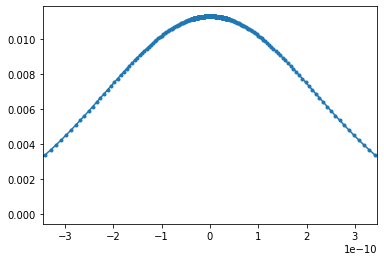

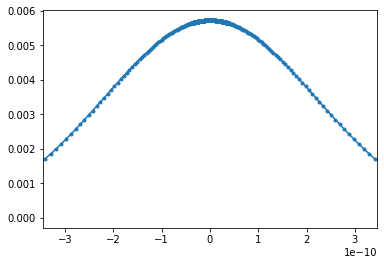

In [17]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_psi_woEnd, np.reshape(eigVecsSort_NeuDir[iEig], (nGrid-2, nGrid-2))[nGrid // 2,:], marker='.')
    ax.set_xlim([5 * psiLargeEtaMin - 4 * psiLargeEtaMax, 5 * psiLargeEtaMax - 4 * psiLargeEtaMin])
    plt.show()

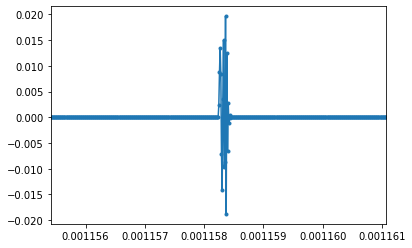

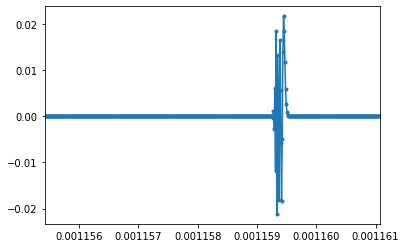

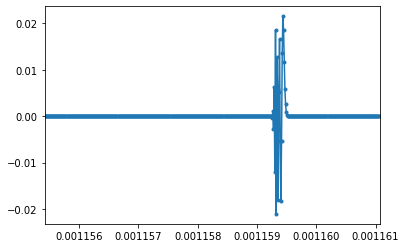

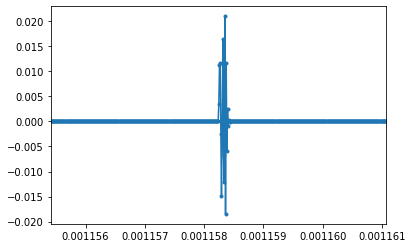

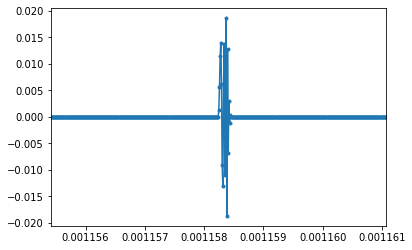

In [18]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_phi_woEnd, np.reshape(eigVecsSort_NeuDir[iEig], (nGrid-2, nGrid-2))[:,nGrid//2], marker=".")
    ax.set_xlim([phiLargeEtaMin, phiLargeEtaMax])
    plt.show()

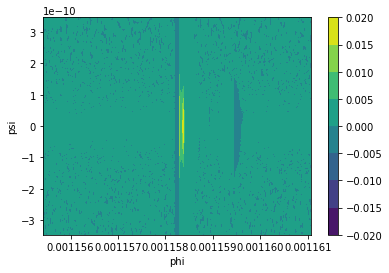

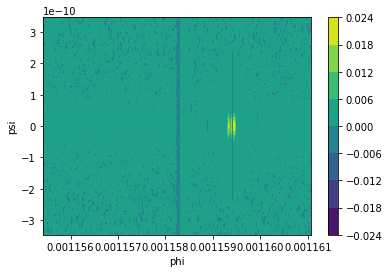

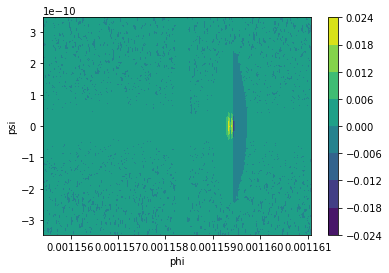

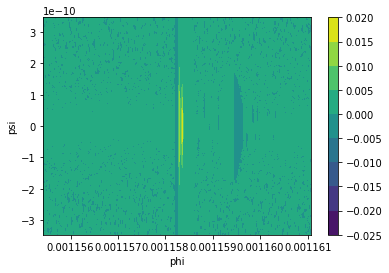

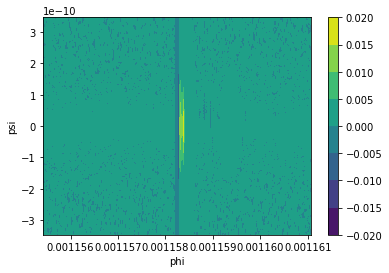

In [19]:
# 固有関数のプロット
for iEig in range(5):   
    fig, ax1 = plt.subplots(1)
    cntr1 = ax1.contourf(customGrid_phi_woEnd, customGrid_psi_woEnd, np.reshape(eigVecsSort_DirDir[iEig], (nGrid-2, nGrid-2)).T)
    fig.colorbar(cntr1, ax=ax1)
    ax1.set_xlabel("phi")
    ax1.set_ylabel("psi")
    ax1.set_xlim([phiLargeEtaMin, phiLargeEtaMax])
    ax1.set_ylim([5 * psiLargeEtaMin - 4 * psiLargeEtaMax, 5 * psiLargeEtaMax - 4 * psiLargeEtaMin])
    plt.show()

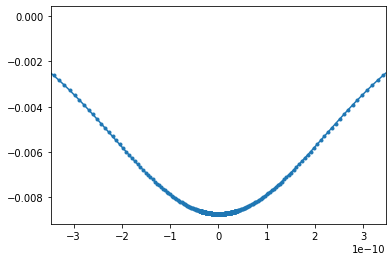

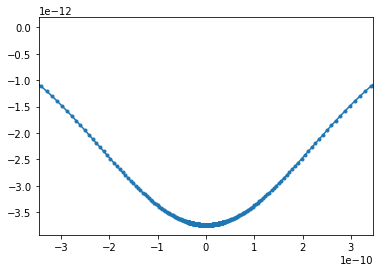

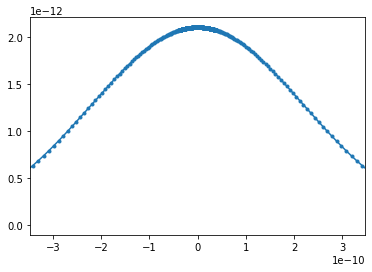

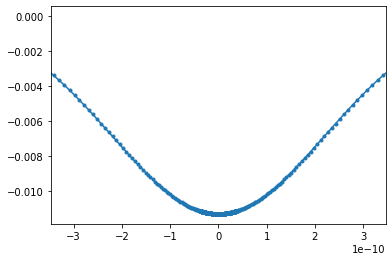

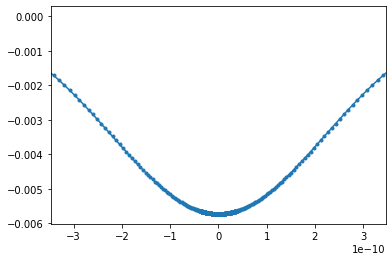

In [20]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_psi_woEnd, np.reshape(eigVecsSort_DirDir[iEig], (nGrid-2, nGrid-2))[nGrid//2,:],marker=".")
    ax.set_xlim([5 * psiLargeEtaMin - 4 * psiLargeEtaMax, 5 * psiLargeEtaMax - 4 * psiLargeEtaMin])
    plt.show()

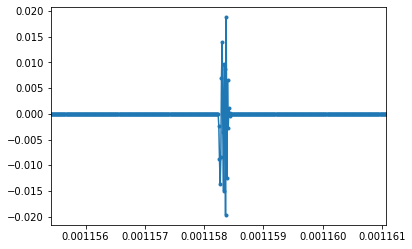

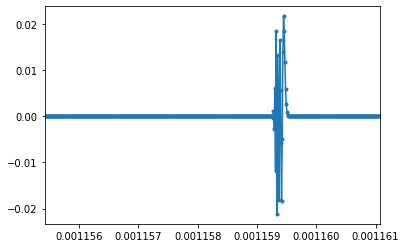

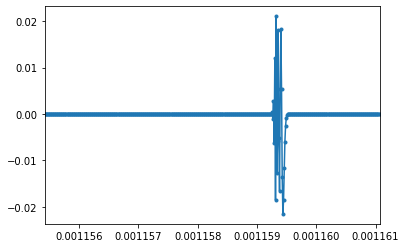

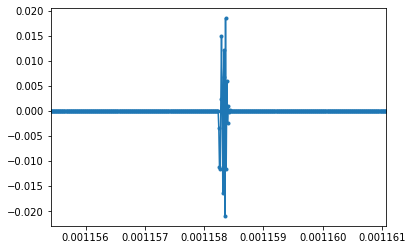

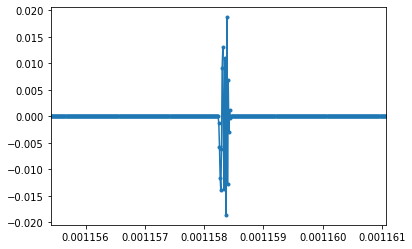

In [21]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_phi_woEnd, np.reshape(eigVecsSort_DirDir[iEig], (nGrid-2, nGrid-2))[:,nGrid//2], marker=".")
    ax.set_xlim([phiLargeEtaMin, phiLargeEtaMax])
    plt.show()